### Reccomendation Systems

The goal is to build a supervised classification model that, based on demographic and socioeconomic data of an adult (age, education level, occupation, marital status, country of origin, etc.), predicts whether the person will earn more or less than $50,000 per year. And develop a reccomendation system to build a career that trespasses the treshold.

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity

#### Loading Data

The data comes from the following URL: https://breathecode.herokuapp.com/asset/internal-link?id=2325&path=adult-census-income.csv

It's the Adult Income Dataset, also known as "Census Income". This information was collected by the U.S. Census Bureau.

In [28]:
df = pd.read_csv("/workspaces/crerov-intro-machine-learning/data/raw/adult-census-income.csv")
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


### Descriptive Analysis

In [29]:
df.shape

(32561, 15)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [31]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Observations

- fnlwgt (final weight) in the Adult dataset represents the number of people in the US population (16+) estimated to have the same demographic characteristics as that specific record. It is a sampling weight derived from Current Population Survey (CPS) files, adjusting for factors like race, age, and sex.
- There are 32561 rows and 15 columns.
- No missing values.
- The data contains 6 numerical features and 9 objects.


### Data Cleaning

In [32]:
# Looking for duplicated data
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32556    False
32557    False
32558    False
32559    False
32560    False
Length: 32561, dtype: bool

In [33]:
# Dropping duplicates if True
if df.duplicated().sum():
        df = df.drop_duplicates()
        
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


Found and removed 24 duplicates.

In [34]:
df["workclass"].value_counts()

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [35]:
df["occupation"].value_counts()

occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
?                    1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

In [36]:
# Replace missing categorical values represented as "?" with the category "Unknown"
df["occupation"] = df["occupation"].replace("?", "Unknown")
df["workclass"] = df["workclass"].replace("?", "Unknown")

In [37]:
# Drop columns that are not relevant for predicting income (education already exists in education.num)
df = df.drop(columns=["fnlwgt", "education"])

### Visualization

In [38]:
# Convert income to numeric: 0 for <=50K, 1 for >50K
df["high_income"] = df["income"].apply(lambda x: 0 if x == "<=50K" else 1)

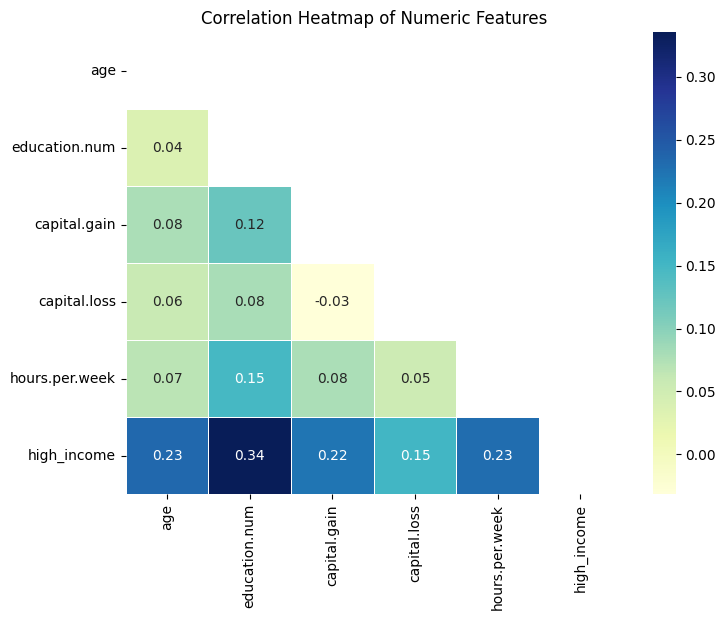

In [39]:
# Correlation matrix for numeric features
numeric_cols = ["age", "education.num", "capital.gain", "capital.loss", "hours.per.week", "high_income"]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, cmap="YlGnBu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

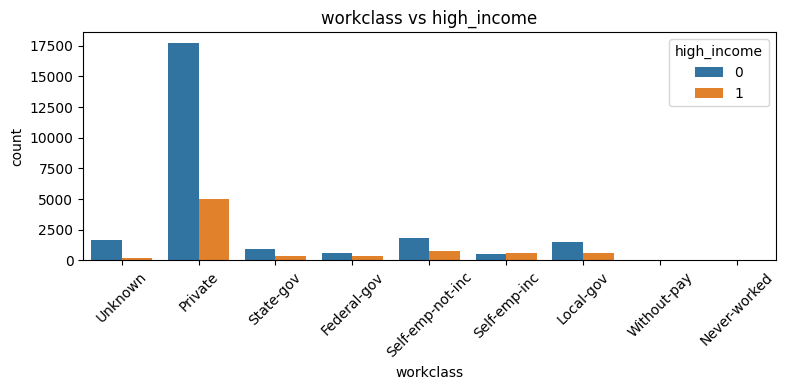

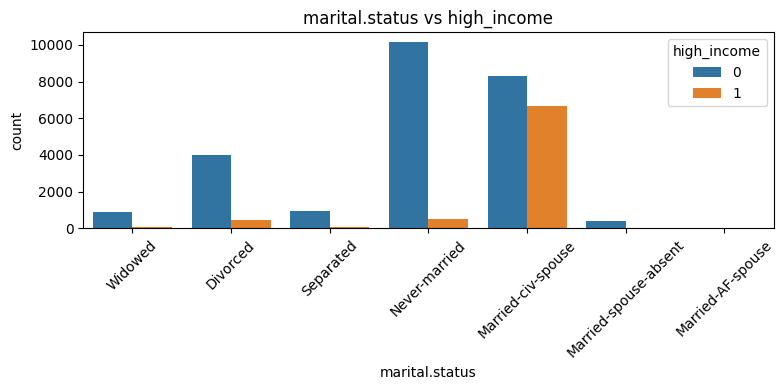

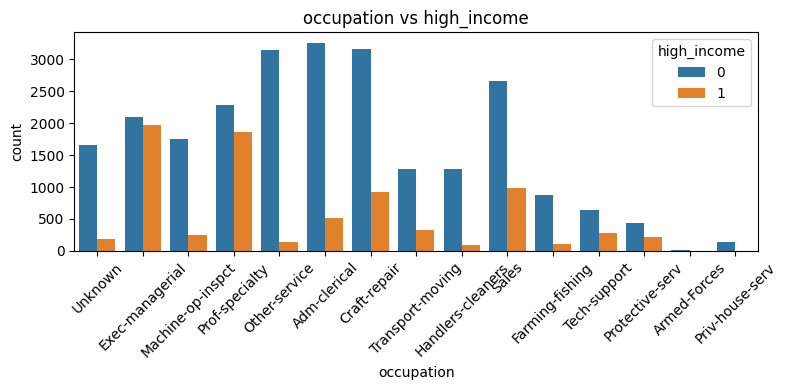

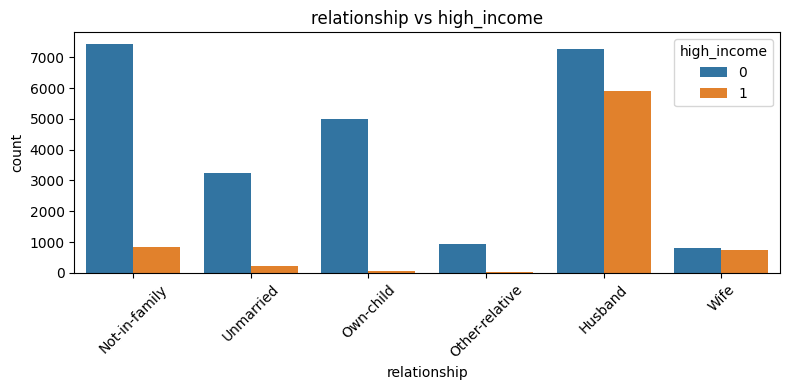

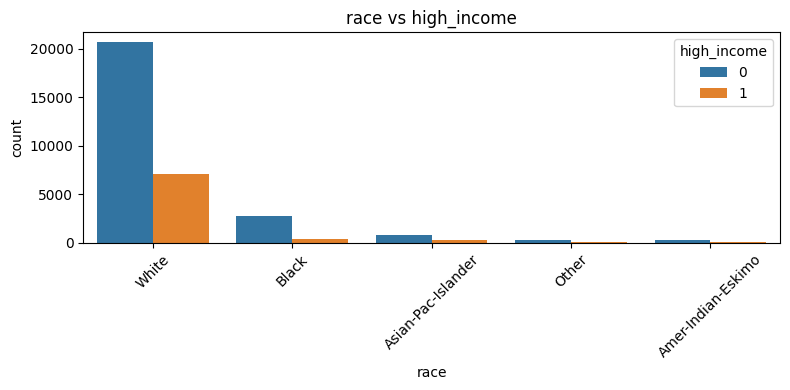

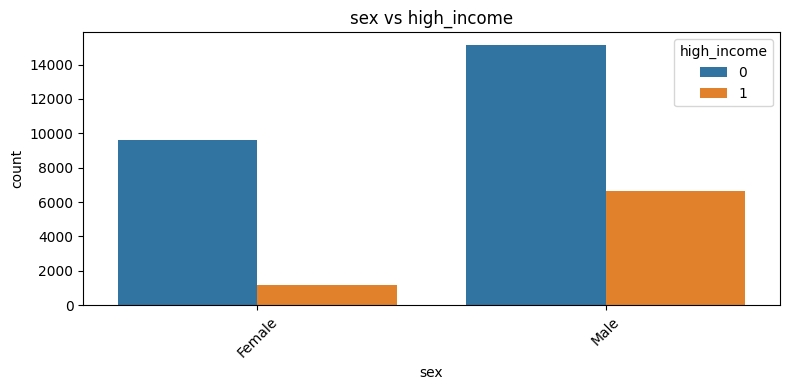

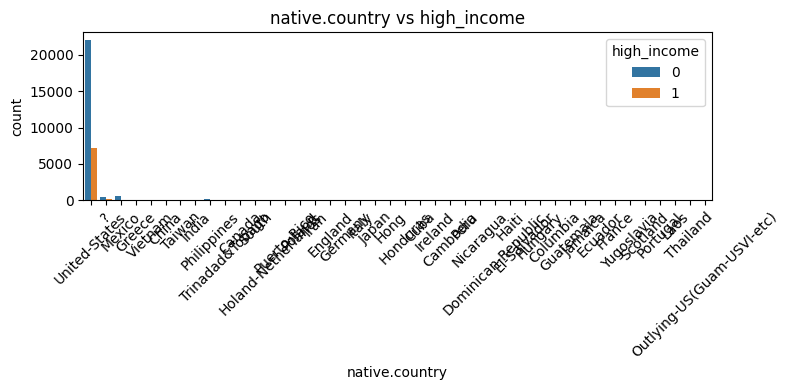

In [40]:
# Visualization for categorical features
cat_cols = ["workclass", "marital.status", "occupation", "relationship", "race", "sex", "native.country"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="high_income")
    plt.title(f"{col} vs high_income")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Native country does not give much information, we could consider dropping it.

### Train/Test Split

In [41]:
X = df.drop(columns=["income", "high_income"])
y = df["high_income"]

# Perform Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)



### One Hot Encoding and Feature Scaling

In [42]:
# Encode categorical columns
cat_columns = cat_cols
encoder = OneHotEncoder(sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[cat_columns])
X_test_encoded = encoder.transform(X_test[cat_columns])

X_train_one_hot = pd.DataFrame(X_train_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_train.index)
X_test_one_hot = pd.DataFrame(X_test_encoded, columns = encoder.get_feature_names_out(cat_columns), index = X_test.index)

X_train_final = pd.concat([X_train.drop(columns = cat_columns), X_train_one_hot], axis=1)
X_test_final  = pd.concat([X_test.drop(columns = cat_columns), X_test_one_hot], axis=1)

In [43]:
#Feature Scaling
scaler = StandardScaler()
scaler.fit(X_train_final)
X_train_scaled = scaler.transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train_final.columns, index = X_train_final.index)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns = X_test_final.columns, index = X_test_final.index)

X_train_scaled.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,0.175224,-0.424522,-0.147221,-0.217763,0.772045,-0.175878,-0.2615,-0.016401,-1.516792,5.314703,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
1,-0.703437,1.134104,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
2,0.321668,-0.424522,-0.147221,-0.217763,3.033711,-0.175878,-0.2615,-0.016401,-1.516792,5.314703,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,46.562682,-0.020562,-2.946762,-0.046434,-0.023198
3,0.541333,0.354791,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198
4,-0.630215,-0.034865,-0.147221,-0.217763,-0.035693,-0.175878,-0.2615,-0.016401,0.659286,-0.188157,...,-0.035629,-0.057239,-0.019604,-0.048864,-0.039232,-0.021476,-0.020562,0.339356,-0.046434,-0.023198


### Random Forest Classificator

In [44]:
# Initialize and train the classifier
clf_model = RandomForestClassifier(random_state=42, n_estimators=100)
clf_model.fit(X_train_scaled, y_train)

# Evaluate the model (as requested in objectives)
y_pred = clf_model.predict(X_test_scaled)
print("Classification Model Performance:")
print(classification_report(y_test, y_pred))

Classification Model Performance:
              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4988
           1       0.70      0.63      0.66      1520

    accuracy                           0.85      6508
   macro avg       0.80      0.77      0.78      6508
weighted avg       0.85      0.85      0.85      6508



### Prepare Content Features


In [45]:
content_cols = ["education.num", "hours.per.week"] + [c for c in X_train_final.columns if "occupation" in c or "workclass" in c]
X_content_train = X_train_final[content_cols]
X_content_test  = X_test_final[content_cols]

### Reccomendation Function

In [46]:
def get_recommendations(user_data, X_train_scaled, X_train_original, y_train, top_k=5):
    """
    Finds high-earning users similar to the input user and returns their common careers.
    """
    
    # We use scaled data for accurate distance calculation
    sim_scores = cosine_similarity(user_data.values.reshape(1, -1), X_train_scaled)[0]
    
    # 2. Filter for only users who actually earn >50K (high_income == 1)
    # We create a temporary series to link similarity scores with income labels
    sim_series = pd.Series(sim_scores, index=y_train.index)
    high_income_sims = sim_series[y_train == 1]
    
    # 3. Get the indices of the most similar high-income earners
    top_indices = high_income_sims.sort_values(ascending=False).head(top_k).index
    
    # 4. Extract the 'winning' paths from the original (non-scaled) training data
    # This makes the results readable (e.g., 'Exec-managerial' instead of 0.45)
    recommendations = X_train_original.loc[top_indices, ["occupation", "education.num"]]
    
    return recommendations

### Example with simulated user


In [48]:
# --- SIMULATED USER TEST ---

# Taking a user that is low profile
target_user_scaled = X_test_scaled.iloc[0]
target_user_id = X_test_scaled.index[0]

print("Simulated User Current Profile:")
print(X_test.iloc[0][["age", "occupation", "education.num"]])

# Get recommendations from high-income peers in the training set
career_recs = get_recommendations(
    target_user_scaled, 
    X_train_scaled, 
    X_train,
    y_train, 
    top_k=5
)

print("\n--- RECOMMENDATIONS TO EXCEED $50K ---")
if not career_recs.empty:
    
    display(career_recs.drop_duplicates())
else:
    print("No similar high-income profiles found.")

Simulated User Current Profile:
age                             53
occupation       Machine-op-inspct
education.num                   10
Name: 0, dtype: object

--- RECOMMENDATIONS TO EXCEED $50K ---


,occupation,education.num
20659,Machine-op-inspct,9
